<a href="https://colab.research.google.com/github/Tilak1578/CGS410_Course_Project/blob/main/Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
drive_path = "/content/drive/MyDrive/Course_Project"
!pip install conllu


In [ ]:
from google.colab import drive
import os, requests
drive.mount('/content/drive')
os.makedirs(drive_path, exist_ok=True)

files = {
"en_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu",
"hi_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu",
"de_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu",
"es_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Spanish-GSD/master/es_gsd-ud-train.conllu",
"fr_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_French-GSD/master/fr_gsd-ud-train.conllu",
"it_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Italian-ISDT/master/it_isdt-ud-train.conllu",
"ru_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Russian-GSD/master/ru_gsd-ud-train.conllu",
"zh_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Chinese-GSD/master/zh_gsd-ud-train.conllu",
"ja_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Japanese-GSD/master/ja_gsd-ud-train.conllu",
"ko_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Korean-GSD/master/ko_gsd-ud-train.conllu",
"ar_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Arabic-PADT/master/ar_padt-ud-train.conllu",
"tr_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Turkish-IMST/master/tr_imst-ud-train.conllu",
"fi_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Finnish-TDT/master/fi_tdt-ud-train.conllu",
"el_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Greek-GDT/master/el_gdt-ud-train.conllu",
"sv_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Swedish-Talbanken/master/sv_talbanken-ud-train.conllu",
"pl_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Polish-PDB/master/pl_pdb-ud-train.conllu",
"da_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Danish-DDT/master/da_ddt-ud-train.conllu",
"nl_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Dutch-Alpino/master/nl_alpino-ud-train.conllu",
"pt_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Portuguese-GSD/master/pt_gsd-ud-train.conllu",
"bg_train":"https://raw.githubusercontent.com/UniversalDependencies/UD_Bulgarian-BTB/master/bg_btb-ud-train.conllu"
}

for name, url in files.items():
    print(f"Downloading {name}...")
    r = requests.get(url)
    if r.status_code == 200:
        with open(os.path.join(drive_path, name + ".conllu"), "wb") as f:
            f.write(r.content)
    else:
        print(f"Failed: {name} ({r.status_code})")

print("All downloads complete.")

Mounted at /content/drive
All downloads complete.


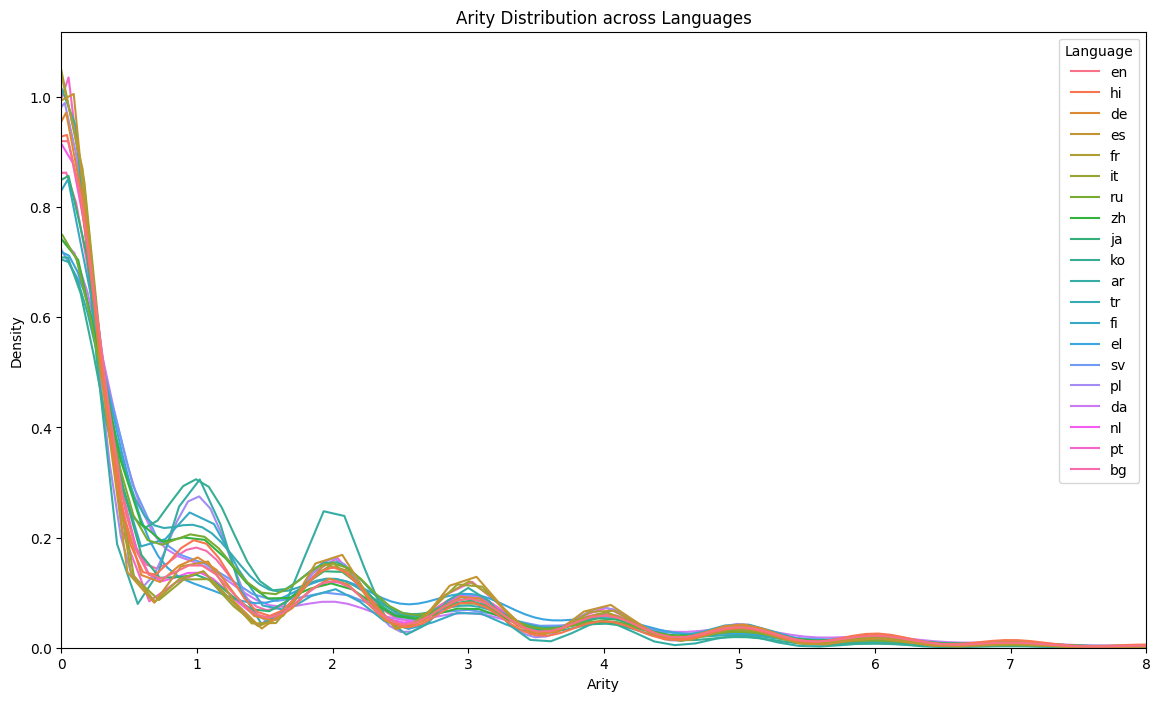

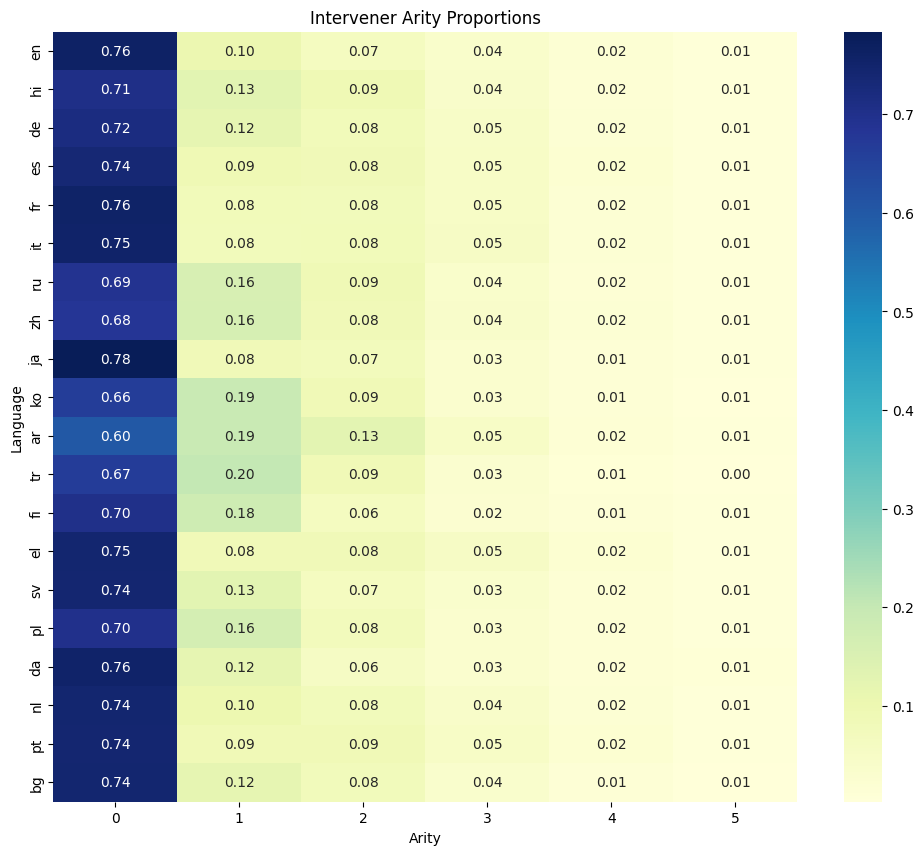

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from conllu import parse_incr
from google.colab import drive

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Arity_Analysis")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

def analyze_language_arity(path):
    all_nodes = []
    intervener_nodes = []

    with open(path, "r", encoding="utf-8") as f:
        for sentence in parse_incr(f):
            out_degrees = {}
            for word in sentence:
                parent = word['head']
                if parent is not None and parent != 0:
                    out_degrees[parent] = out_degrees.get(parent, 0) + 1

            for word in sentence:
                all_nodes.append(out_degrees.get(word['id'], 0))

            for word in sentence:
                h_id = word['head']
                d_id = word['id']

                if h_id == 0 or h_id is None:
                    continue

                left, right = min(h_id, d_id), max(h_id, d_id)
                for i in range(left + 1, right):
                    intervener_nodes.append(out_degrees.get(i, 0))

    return all_nodes, intervener_nodes

kde_records = []
heatmap_records = []

conllu_files = [f for f in os.listdir(drive_root) if f.endswith('.conllu')]

for file_name in conllu_files:
    lang_name = file_name.split('_')[0]
    full_path = os.path.join(drive_root, file_name)

    node_data, intv_data = analyze_language_arity(full_path)

    kde_records.append(pd.DataFrame({'Arity': node_data, 'Language': lang_name}))

    distribution = pd.Series(intv_data).value_counts(normalize=True).sort_index()
    distribution.name = lang_name
    heatmap_records.append(distribution)

combined_kde_df = pd.concat(kde_records)
plt.figure(figsize=(14, 8))
sns.kdeplot(data=combined_kde_df, x='Arity', hue='Language', common_norm=False, bw_adjust=2)
plt.title("Arity Distribution across Languages")
plt.xlim(0, 8)
plt.savefig(os.path.join(save_dir, "arity_kde.png"))
plt.show()

matrix_df = pd.concat(heatmap_records, axis=1).fillna(0).T
matrix_df = matrix_df.iloc[:, :6]

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Intervener Arity Proportions")
plt.xlabel("Arity")
plt.ylabel("Language")
plt.savefig(os.path.join(save_dir, "intervener_heatmap.png"))
plt.show()

In [ ]:
import os
import random
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from conllu import parse_incr
from google.colab import drive

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Arity_Analysis")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

def process_language(path, lang):
    observations = []

    with open(path, "r", encoding="utf-8") as f:
        for sentence in parse_incr(f):
            nodes = [t for t in sentence if isinstance(t['id'], int)]
            if not nodes:
                continue

            out_degrees = {}
            for t in nodes:
                h = t['head']
                if h is not None and h != 0:
                    out_degrees[h] = out_degrees.get(h, 0) + 1

            dependencies = []
            for t in nodes:
                if t['head'] is not None and t['head'] != 0:
                    dependencies.append((t['head'], t['id']))

            for h_id, d_id in dependencies:
                real_dist = abs(h_id - d_id)
                real_arity_sum = 0
                for i in range(min(h_id, d_id) + 1, max(h_id, d_id)):
                    real_arity_sum += out_degrees.get(i, 0)

                observations.append({
                    'arity': real_arity_sum,
                    'condition': 1,
                    'length': real_dist
                })

            positions = [t['id'] for t in nodes]
            shuffled_positions = positions[:]
            random.shuffle(shuffled_positions)
            pos_map = dict(zip(positions, shuffled_positions))

            for h_id, d_id in dependencies:
                rand_h_pos = pos_map[h_id]
                rand_d_pos = pos_map[d_id]
                rand_dist = abs(rand_h_pos - rand_d_pos)

                rand_arity_sum = 0
                low, high = min(rand_h_pos, rand_d_pos), max(rand_h_pos, rand_d_pos)

                for orig_id, new_pos in pos_map.items():
                    if low < new_pos < high:
                        rand_arity_sum += out_degrees.get(orig_id, 0)

                observations.append({
                    'arity': rand_arity_sum,
                    'condition': 0,
                    'length': rand_dist
                })

    return pd.DataFrame(observations)

summary_rows = []
all_results = []

conllu_files = sorted([f for f in os.listdir(drive_root) if f.endswith('.conllu')])

for file_name in conllu_files:
    lang_code = file_name.split('_')[0]
    file_path = os.path.join(drive_root, file_name)

    df = process_language(file_path, lang_code)

    model = smf.glm(formula="arity ~ condition + length",
                    data=df,
                    family=sm.families.Poisson()).fit()

    beta_1 = model.params['condition']
    beta_2 = model.params['length']
    z_score = model.tvalues['condition']
    p_value = model.pvalues['condition']

    is_rejected = "Reject H0" if (beta_1 < 0 and (p_value / 2) < 0.05) else "Fail to Reject"

    summary_rows.append({
        'Language': lang_code,
        'Beta_1': round(beta_1, 4),
        'Z_Statistic': round(z_score, 4),
        'Result': is_rejected
    })

    all_results.append({
        'language': lang_code,
        'beta_0': model.params['Intercept'],
        'beta_1': beta_1,
        'beta_2': beta_2,
        'z_stat': z_score,
        'p_value_one_tailed': p_value / 2,
        'irr': os.path.exp(beta_1) if hasattr(os, 'exp') else 2.71828**beta_1,
        'decision': is_rejected
    })

pd.DataFrame(all_results).to_csv(os.path.join(save_dir, "poisson_regression_summary.csv"), index=False)

output_table = pd.DataFrame(summary_rows)
print(output_table.to_string(index=False))

Language  Beta_1  Z_Statistic    Result
      ar -1.6584   -1096.0117 Reject H0
      bg -1.0633    -313.1289 Reject H0
      da -1.1266    -311.9581 Reject H0
      de -0.9493    -523.9140 Reject H0
      el -1.3048    -280.6767 Reject H0
      en -1.3587    -590.5879 Reject H0
      es -1.4392    -938.0254 Reject H0
      fi -1.3257    -481.0656 Reject H0
      fr -1.7829   -1082.2753 Reject H0
      hi -1.0298    -582.1650 Reject H0
      it -1.6911    -916.0463 Reject H0
      ja -1.7701    -603.2262 Reject H0
      ko -1.0391    -225.4686 Reject H0
      nl -0.8258    -353.9928 Reject H0
      pl -1.0850    -528.7421 Reject H0
      pt -1.3458    -708.3096 Reject H0
      ru -1.2124    -327.5100 Reject H0
      sv -1.2551    -296.0357 Reject H0
      tr -0.9109    -137.9050 Reject H0
      zh -0.9966    -363.6454 Reject H0


/tmp/ipykernel_8190/1935441098.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df, x='beta_1', y='language', join=False, color='darkblue')


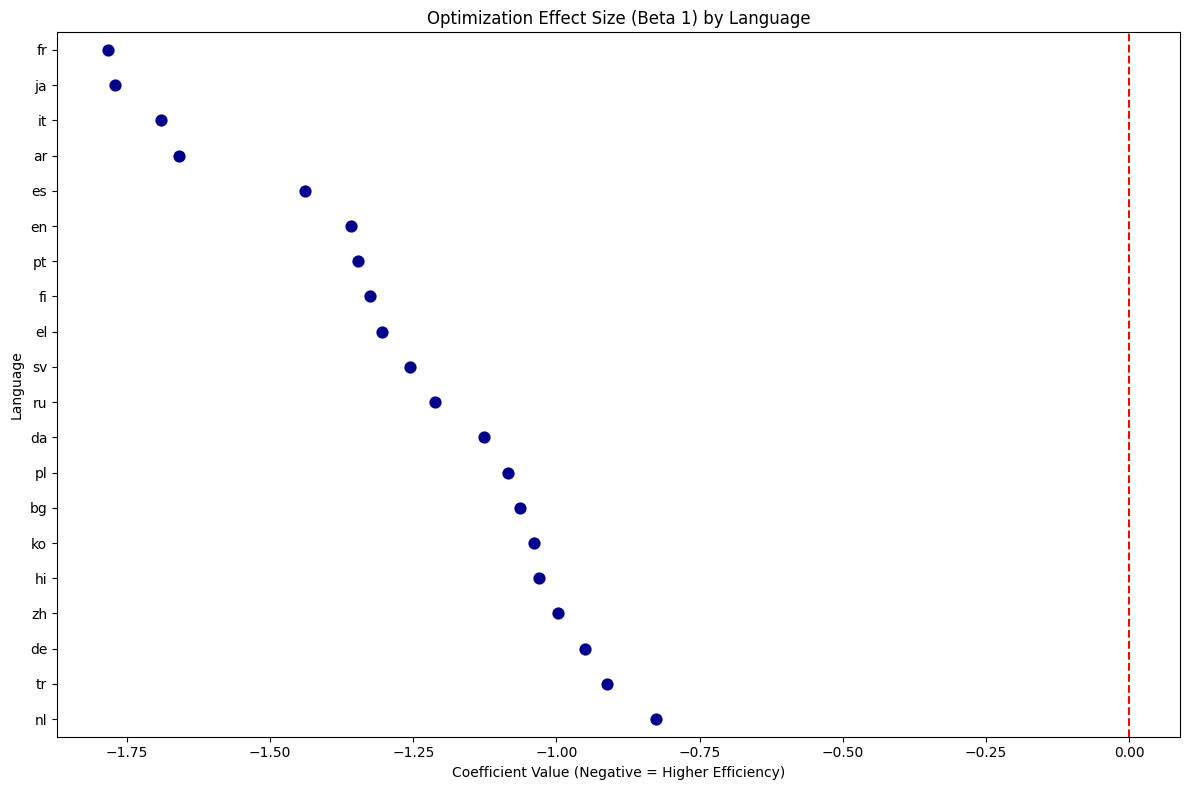

/tmp/ipykernel_8190/1935441098.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='z_stat', y='language', palette=colors)


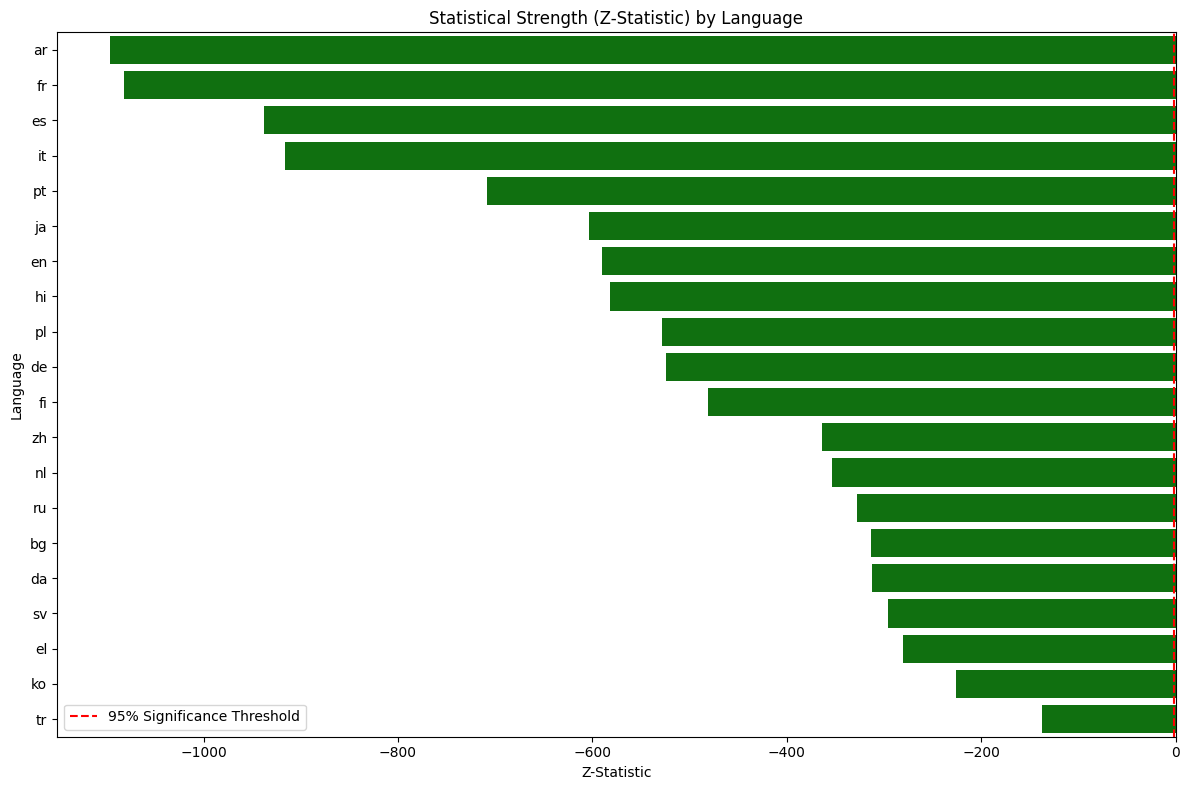

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Arity_Analysis")
data_path = os.path.join(save_dir, "poisson_regression_summary.csv")

df = pd.read_csv(data_path)
df = df.sort_values('beta_1')

plt.figure(figsize=(12, 8))
sns.pointplot(data=df, x='beta_1', y='language', join=False, color='darkblue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Optimization Effect Size (Beta 1) by Language")
plt.xlabel("Coefficient Value (Negative = Higher Efficiency)")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "coefficient_forest_plot.png"))
plt.show()

df = df.sort_values('z_stat')
plt.figure(figsize=(12, 8))
colors = ['green' if z < -1.645 else 'grey' for z in df['z_stat']]
sns.barplot(data=df, x='z_stat', y='language', palette=colors)
plt.axvline(-1.645, color='red', linestyle='--', label='95% Significance Threshold')
plt.title("Statistical Strength (Z-Statistic) by Language")
plt.xlabel("Z-Statistic")
plt.ylabel("Language")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "z_statistic_bars.png"))
plt.show()

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/Course_Project"
output_dir = os.path.join(drive_path, "Dependency_Analysis")
os.makedirs(output_dir, exist_ok=True)

languages = [
    'zh', 'tr', 'sv', 'ru', 'pt', 'pl', 'nl', 'ko', 'ja', 'it',
    'hi', 'fr', 'fi', 'es', 'en', 'el', 'de', 'da', 'bg', 'ar'
]

dataset = []

def parse_conllu(file_path):
    sentences = []
    current_sent = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#'):
                continue
            if line.strip() == '':
                if current_sent:
                    sentences.append(current_sent)
                    current_sent = []
            else:
                current_sent.append(line.strip().split('\t'))
    return sentences

for lang in languages:
    path = os.path.join(drive_path, f"{lang}_train.conllu")
    if not os.path.exists(path):
        continue

    sentences = parse_conllu(path)
    for sent in sentences:
        tree = {int(node[0]): int(node[6]) for node in sent if node[0].isdigit()}

        for dep, head in tree.items():
            if head == 0:
                continue

            left, right = min(dep, head), max(dep, head)
            if right - left <= 1:
                continue

            for i in range(left + 1, right):
                if i not in tree:
                    continue

                i_head = tree[i]
                if i_head == head:
                    role = 'Head-Modifier (H)'
                elif i_head == dep:
                    role = 'Dependent-Modifier (D)'
                else:
                    role = 'Independent (I)'

                dataset.append({'Language': lang, 'Category': role})

analysis_df = pd.DataFrame(dataset)

plt.figure(figsize=(12, 6))
sns.kdeplot(data=analysis_df, x=analysis_df.index, hue='Category', fill=True, common_norm=False)
plt.title('Distribution of Intervener Categories')
plt.xlabel('Observation Index')
plt.ylabel('Density')
plt.savefig(os.path.join(output_dir, 'intervener_kernel_density.png'))
plt.close()

counts = analysis_df.groupby(['Language', 'Category']).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0)

plt.figure(figsize=(14, 10))
sns.heatmap(proportions, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Relative Frequency of Intervener Roles Across Languages')
plt.savefig(os.path.join(output_dir, 'intervener_role_heatmap.png'))
plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import drive
import patsy.contrasts as sx

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Course_Project"
output_path = os.path.join(base_path, "Dependency_Analysis")
os.makedirs(output_path, exist_ok=True)

languages = [
    'zh', 'tr', 'sv', 'ru', 'pt', 'pl', 'nl', 'ko', 'ja', 'it',
    'hi', 'fr', 'fi', 'es', 'en', 'el', 'de', 'da', 'bg', 'ar'
]

results = []

for lang in languages:
    file_path = os.path.join(base_path, f"{lang}_train.conllu")
    if not os.path.exists(file_path):
        continue

    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        sentence = []
        for line in f:
            if line.startswith('#'):
                continue
            if line.strip() == '':
                if sentence:
                    nodes = {int(n[0]): int(n[6]) for n in sentence if n[0].isdigit()}
                    for dep, head in nodes.items():
                        if head == 0: continue

                        start, end = min(dep, head), max(dep, head)
                        dist = end - start
                        if dist <= 1: continue

                        counts = {'H': 0, 'D': 0, 'I': 0}
                        for i in range(start + 1, end):
                            if i not in nodes: continue
                            if nodes[i] == head:
                                counts['H'] += 1
                            elif nodes[i] == dep:
                                counts['D'] += 1
                            else:
                                counts['I'] += 1

                        for cat in ['H', 'D', 'I']:
                            records.append({
                                'count': counts[cat],
                                'category': cat,
                                'log_dist': np.log(dist)
                            })
                    sentence = []
            else:
                sentence.append(line.strip().split('\t'))

    if records:
        df = pd.DataFrame(records)

        model = smf.glm(
            formula="count ~ C(category, sx.Treatment(reference='I'))",
            data=df,
            family=sm.families.Poisson(),
            offset=df['log_dist']
        ).fit()

        b_h = model.params["C(category, sx.Treatment(reference='I'))[T.H]"]
        z_h = model.tvalues["C(category, sx.Treatment(reference='I'))[T.H]"]
        p_h = model.pvalues["C(category, sx.Treatment(reference='I'))[T.H]"] / 2 if z_h < 0 else 1 - (model.pvalues["C(category, sx.Treatment(reference='I'))[T.H]"] / 2)

        b_d = model.params["C(category, sx.Treatment(reference='I'))[T.D]"]
        z_d = model.tvalues["C(category, sx.Treatment(reference='I'))[T.D]"]
        p_d = model.pvalues["C(category, sx.Treatment(reference='I'))[T.D]"] / 2 if z_d < 0 else 1 - (model.pvalues["C(category, sx.Treatment(reference='I'))[T.D]"] / 2)

        results.append({
            'Language': lang,
            'Beta_H_vs_I': b_h,
            'Z_H': z_h,
            'P_H_OneTailed': p_h,
            'Result_H': 'Reject Null' if p_h < 0.05 and b_h < 0 else 'Fail to Reject',
            'Beta_D_vs_I': b_d,
            'Z_D': z_d,
            'P_D_OneTailed': p_d,
            'Result_D': 'Reject Null' if p_d < 0.05 and b_d < 0 else 'Fail to Reject'
        })

summary_df = pd.DataFrame(results)
summary_df.to_csv(os.path.join(output_path, "language_hypothesis_testing.csv"), index=False)

print(summary_df[['Language', 'Z_H', 'Result_H', 'Z_D', 'Result_D']].to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Language         Z_H    Result_H         Z_D    Result_D
      zh -200.918661 Reject Null -256.302130 Reject Null
      tr  -54.995115 Reject Null  -99.323031 Reject Null
      sv  -64.844438 Reject Null -130.377472 Reject Null
      ru -141.517212 Reject Null -165.789371 Reject Null
      pt -279.478532 Reject Null -304.998045 Reject Null
      pl -217.219260 Reject Null -286.005040 Reject Null
      nl -159.156779 Reject Null -283.992764 Reject Null
      ko -101.259257 Reject Null -145.612776 Reject Null
      ja  -68.947630 Reject Null -161.653866 Reject Null
      it -251.042492 Reject Null -309.905705 Reject Null
      hi -280.107197 Reject Null -382.777533 Reject Null
      fr -273.173833 Reject Null -328.104294 Reject Null
      fi -118.442614 Reject Null -220.197021 Reject Null
      es -349.704324 Reject Null -376.341552 Reject Null
      en -149.90

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


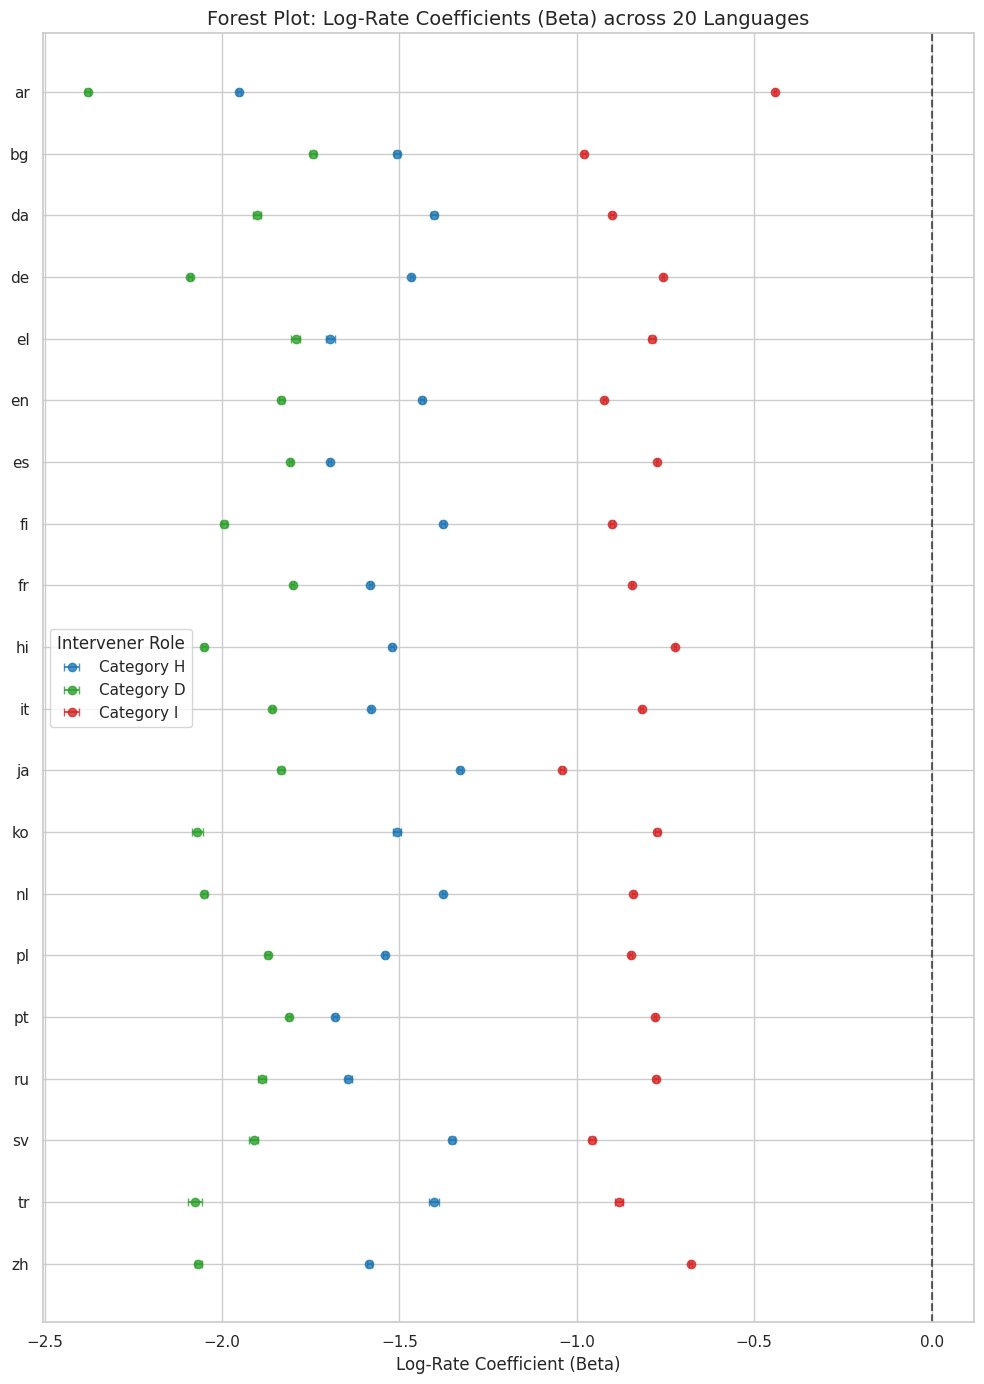

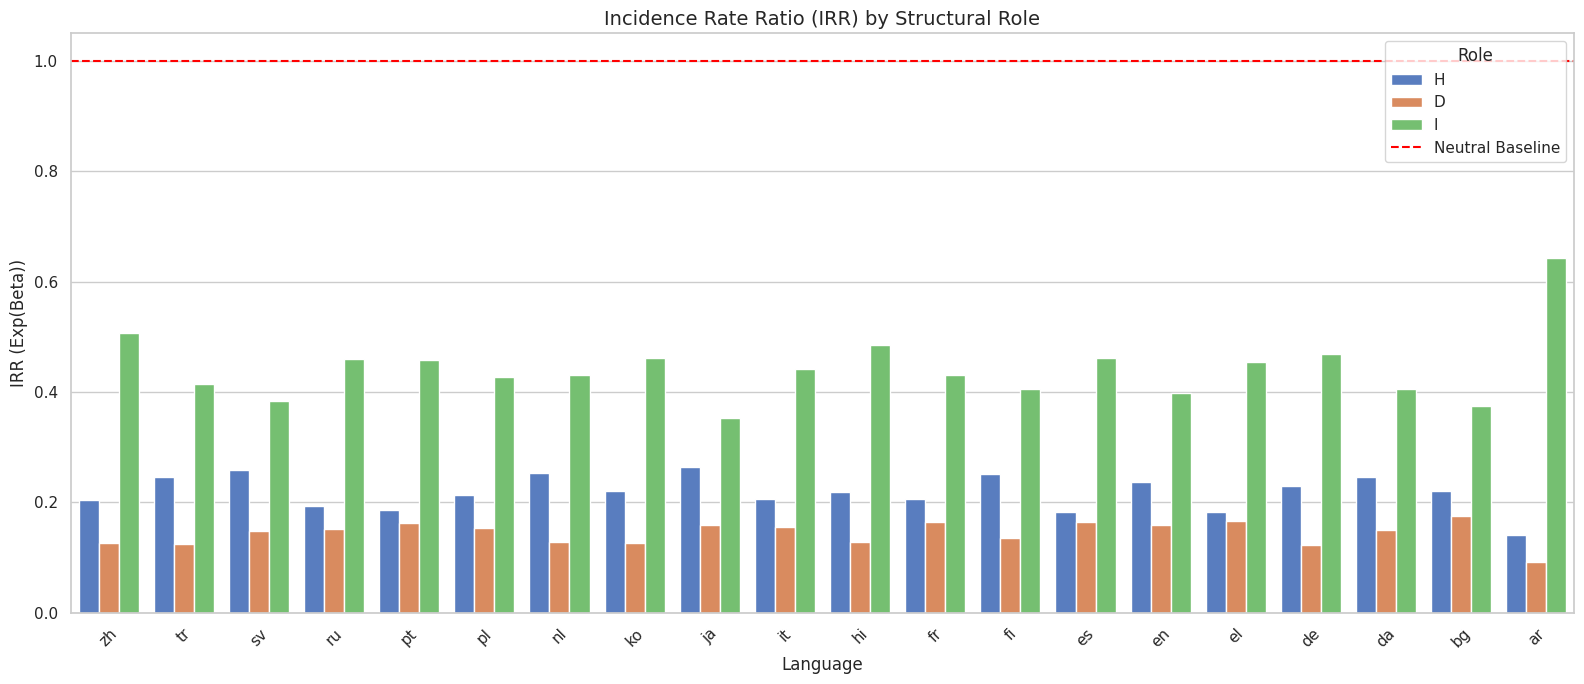

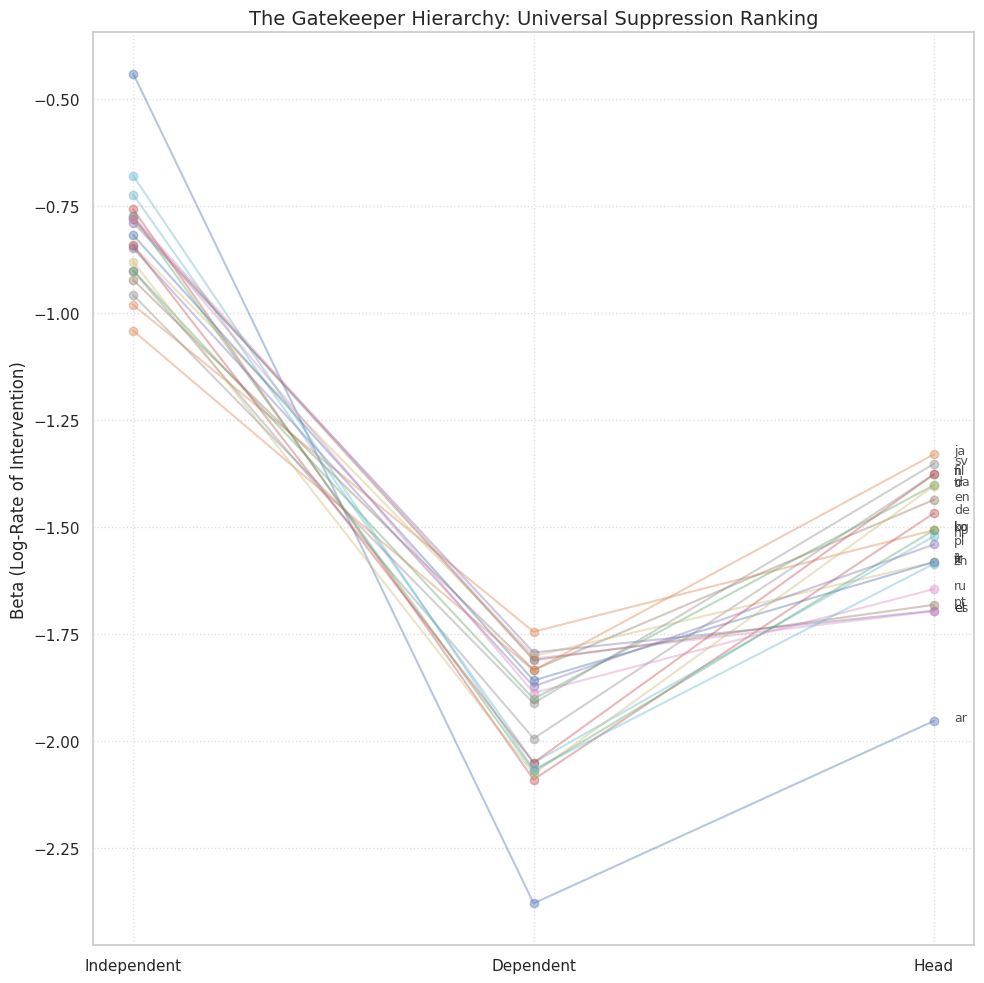

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import drive

drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/Course_Project"
output_dir = os.path.join(drive_path, "Dependency_Analysis")
os.makedirs(output_dir, exist_ok=True)

languages = ['zh', 'tr', 'sv', 'ru', 'pt', 'pl', 'nl', 'ko', 'ja', 'it',
             'hi', 'fr', 'fi', 'es', 'en', 'el', 'de', 'da', 'bg', 'ar']

plot_data = []

for lang in languages:
    file_path = os.path.join(drive_path, f"{lang}_train.conllu")
    if not os.path.exists(file_path): continue

    observations = []
    with open(file_path, 'r', encoding='utf-8') as f:
        sentence = []
        for line in f:
            if line.strip() == '' and sentence:
                nodes = {int(n[0]): int(n[6]) for n in sentence if n[0].isdigit()}
                for dep, head in nodes.items():
                    if head == 0: continue
                    start, end = min(dep, head), max(dep, head)
                    dist = end - start
                    if dist <= 1: continue

                    counts = {'H': 0, 'D': 0, 'I': 0}
                    for i in range(start + 1, end):
                        if i in nodes:
                            if nodes[i] == head: counts['H'] += 1
                            elif nodes[i] == dep: counts['D'] += 1
                            else: counts['I'] += 1

                    for cat in ['H', 'D', 'I']:
                        observations.append({'count': counts[cat], 'category': cat, 'log_dist': np.log(dist)})
                sentence = []
            elif not line.startswith('#'):
                sentence.append(line.strip().split('\t'))

    if observations:
        df_lang = pd.DataFrame(observations)
        model = smf.glm(formula="count ~ category - 1",
                        data=df_lang, family=sm.families.Poisson(),
                        offset=df_lang['log_dist']).fit()

        conf = model.conf_int()
        for cat in ['H', 'D', 'I']:
            p_name = f"category[{cat}]"
            plot_data.append({
                'Language': lang, 'Category': cat,
                'Beta': model.params[p_name],
                'Lower': conf.loc[p_name, 0], 'Upper': conf.loc[p_name, 1],
                'IRR': np.exp(model.params[p_name])
            })

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 14))
sns.set_theme(style="whitegrid")
colors = {'H': '#1f77b4', 'D': '#2ca02c', 'I': '#d62728'}
for cat in ['H', 'D', 'I']:
    sub = df_plot[df_plot['Category'] == cat]
    plt.errorbar(sub['Beta'], sub['Language'],
                 xerr=[sub['Beta'] - sub['Lower'], sub['Upper'] - sub['Beta']],
                 fmt='o', label=f'Category {cat}', color=colors[cat], alpha=0.8, capsize=3)

plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Forest Plot: Log-Rate Coefficients (Beta) across 20 Languages', fontsize=14)
plt.xlabel('Log-Rate Coefficient (Beta)')
plt.legend(title='Intervener Role')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'forest_plot_betas.png'))

plt.figure(figsize=(16, 7))
sns.barplot(data=df_plot, x='Language', y='IRR', hue='Category', palette='muted')
plt.axhline(1, color='red', linestyle='--', label='Neutral Baseline')
plt.title('Incidence Rate Ratio (IRR) by Structural Role', fontsize=14)
plt.ylabel('IRR (Exp(Beta))')
plt.xticks(rotation=45)
plt.legend(title='Role')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'irr_grouped_barplot.png'))

pivot_slope = df_plot.pivot(index='Language', columns='Category', values='Beta')
plt.figure(figsize=(10, 10))
cat_order = ['I', 'D', 'H']
cat_labels = ['Independent', 'Dependent', 'Head']
for lang in pivot_slope.index:
    y_vals = [pivot_slope.loc[lang, c] for c in cat_order]
    plt.plot(cat_labels, y_vals, marker='o', alpha=0.4, linewidth=1.5)
    plt.text(2.05, y_vals[2], lang, fontsize=9, alpha=0.8)

plt.title('The Gatekeeper Hierarchy: Universal Suppression Ranking', fontsize=14)
plt.ylabel('Beta (Log-Rate of Intervention)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'structural_ranking_slopegraph.png'))

Processing Weight Filter for: en
Processing Weight Filter for: hi
Processing Weight Filter for: de
Processing Weight Filter for: es
Processing Weight Filter for: fr
Processing Weight Filter for: it
Processing Weight Filter for: ru
Processing Weight Filter for: zh
Processing Weight Filter for: ja
Processing Weight Filter for: ko
Processing Weight Filter for: ar
Processing Weight Filter for: tr
Processing Weight Filter for: fi
Processing Weight Filter for: el
Processing Weight Filter for: sv
Processing Weight Filter for: pl
Processing Weight Filter for: da
Processing Weight Filter for: nl
Processing Weight Filter for: pt
Processing Weight Filter for: bg


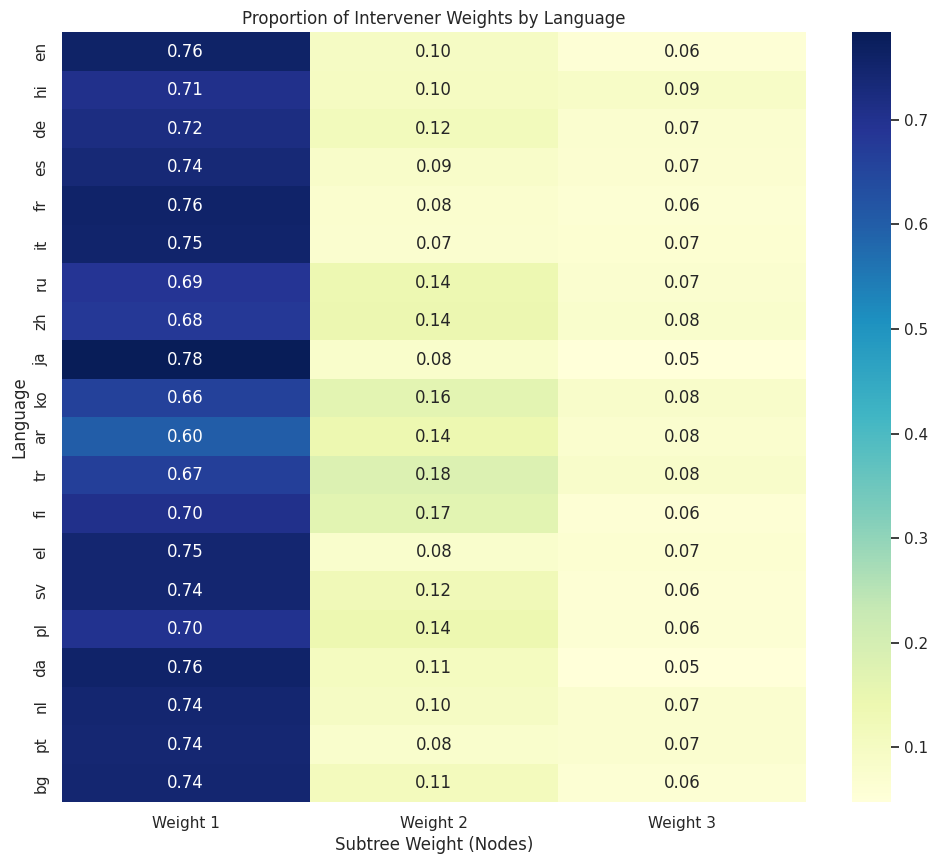

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from conllu import parse_incr
from google.colab import drive
import io

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Subtree_Weight_Analysis")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

def get_subtree_weights(sentence):
    weights = {}
    for word in sentence:
        if isinstance(word['id'], int):
            weights[word['id']] = 1
        else:
            continue

    heads = {word['id']: word['head'] for word in sentence if isinstance(word['id'], int)}

    ids = sorted(weights.keys(), reverse=True)

    for i in ids:
        h = heads.get(i)
        if h is not None and h in weights:
            weights[h] += weights[i]
    return weights

def analyze_weight_filter(path):
    intervener_weights = []

    with io.open(path, "r", encoding="utf-8") as f:
        for sentence in parse_incr(f):
            sent_weights = get_subtree_weights(sentence)

            for word in sentence:
                if not isinstance(word['id'], int) or not isinstance(word['head'], int):
                    continue

                h_id = word['head']
                d_id = word['id']

                if h_id == 0 or h_id is None:
                    continue

                left, right = min(h_id, d_id), max(h_id, d_id)
                for i in range(left + 1, right):
                    if i in sent_weights:
                        intervener_weights.append(sent_weights[i])

    return intervener_weights

heatmap_records = []
conllu_files = [f for f in os.listdir(drive_root) if f.endswith('.conllu')]

for file_name in conllu_files:
    lang_name = file_name.split('_')[0]
    full_path = os.path.join(drive_root, file_name)

    print("Processing Weight Filter for: " + lang_name)
    intv_data = analyze_weight_filter(full_path)

    if not intv_data:
        continue

    dist = pd.Series(intv_data).value_counts(normalize=True).sort_index()
    dist.name = lang_name
    heatmap_records.append(dist)

matrix_df = pd.concat(heatmap_records, axis=1).fillna(0).T
matrix_df = matrix_df.iloc[:, :3]
matrix_df.columns = ["Weight 1", "Weight 2", "Weight 3"]

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Proportion of Intervener Weights by Language")
plt.xlabel("Subtree Weight (Nodes)")
plt.ylabel("Language")
plt.savefig(os.path.join(save_dir, "weight_filter_heatmap.png"))
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import random
import io
import math
import warnings
from conllu import parse_incr
from google.colab import drive
from scipy.stats import norm

warnings.filterwarnings('ignore')

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Subtree_Weight_Analysis")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

def get_subtree_weights(sentence):
    weights = {}
    for word in sentence:
        if isinstance(word['id'], int):
            weights[word['id']] = 1
        else:
            continue

    heads = {}
    for word in sentence:
        if isinstance(word['id'], int):
            head_val = word['head']
            if isinstance(head_val, int):
                heads[word['id']] = head_val
            elif head_val is None:
                heads[word['id']] = 0
            else:
                try:
                    heads[word['id']] = int(head_val)
                except (ValueError, TypeError):
                    heads[word['id']] = 0

    ids = sorted(weights.keys(), reverse=True)

    for i in ids:
        h = heads.get(i)
        if isinstance(h, int) and h in weights:
            weights[h] += weights[i]
    return weights

def extract_obs(sentence, weights, shuffle=False):
    nodes = [word['id'] for word in sentence if isinstance(word['id'], int)]
    if shuffle:
        shf = list(nodes)
        random.shuffle(shf)
        pos = {node: i for i, node in enumerate(shf)}
    else:
        pos = {node: i for i, node in enumerate(nodes)}

    obs = []
    for word in sentence:
        if not isinstance(word['id'], int) or not isinstance(word['head'], int):
            continue

        h_id, d_id = word['head'], word['id']
        if h_id == 0 or h_id is None: continue

        if h_id not in pos or d_id not in pos: continue

        p1, p2 = pos[h_id], pos[d_id]
        l, r = min(p1, p2), max(p1, p2)
        dist = r - l
        if dist > 1:
            for n_id, p_val in pos.items():
                if l < p_val < r:
                    obs.append({'dist': dist, 'weight': weights[n_id]})
    return obs

def run_model(data):
    if not data: return None, None, None
    df = pd.DataFrame(data)
    counts = df.groupby(['dist', 'weight']).size().reset_index(name='y')
    counts['log_dist'] = np.log(counts['dist'])
    X = sm.add_constant(counts[['weight']])
    try:
        res = sm.GLM(counts['y'], X, family=sm.families.Poisson(), offset=counts['log_dist']).fit()
        return res.params['weight'], res.bse['weight'], res.tvalues['weight']
    except:
        return None, None, None

conllu_files = [f for f in os.listdir(drive_root) if f.endswith('.conllu')]
all_results = []

header = "{:<6} | {:<8} | {:<8} | {:<8} | {:<12}"
print(header.format("Lang", "Beta_R", "Wald_Z", "Z_Diff", "Conclusion"))
print("-" * 55)

for f_name in conllu_files:
    lang = f_name.split('_')[0]
    path = os.path.join(drive_root, f_name)
    r_obs, s_obs = [], []
    with io.open(path, "r", encoding="utf-8") as f:
        for sent in parse_incr(f):
            w = get_subtree_weights(sent)
            r_obs.extend(extract_obs(sent, w, False))
            s_obs.extend(extract_obs(sent, w, True))

    r_b, r_se, r_z = run_model(r_obs)
    s_b, s_se, s_z = run_model(s_obs)

    if r_b is not None and s_b is not None:
        z_diff = (r_b - s_b) / math.sqrt(r_se**2 + s_se**2)

        test1 = r_z < -1.645
        test2 = z_diff < -1.645

        conc = "Efficient" if (test1 and test2) else "Insignificant"

        all_results.append({
            'Language': lang,
            'Real_Beta': r_b,
            'Real_Wald_Z': r_z,
            'Rand_Beta': s_b,
            'Rand_Wald_Z': s_z,
            'Z_Diff': z_diff,
            'Conclusion': conc
        })
        print(header.format(lang, round(r_b, 3), round(r_z, 2), round(z_diff, 2), conc))

pd.DataFrame(all_results).to_csv(os.path.join(save_dir, "dual_test_results.csv"), index=False)

Lang   | Beta_R   | Wald_Z   | Z_Diff   | Conclusion  
-------------------------------------------------------
en     | -0.956   | -639.92  | -263.95  | Efficient   
hi     | -0.847   | -774.01  | -211.3   | Efficient   
de     | -0.888   | -791.09  | -244.69  | Efficient   
es     | -0.74    | -857.81  | -319.51  | Efficient   
ru     | -0.794   | -378.14  | -152.73  | Efficient   
zh     | -0.854   | -504.98  | -139.71  | Efficient   
ja     | -1.002   | -516.23  | -218.16  | Efficient   
ko     | -0.846   | -303.0   | -87.56   | Efficient   
tr     | -0.947   | -220.0   | -64.33   | Efficient   
el     | -0.805   | -295.85  | -121.77  | Efficient   
sv     | -0.954   | -351.28  | -133.57  | Efficient   
pl     | -0.836   | -710.93  | -283.45  | Efficient   
da     | -0.901   | -412.42  | -158.74  | Efficient   
nl     | -0.944   | -641.81  | -200.68  | Efficient   
pt     | -0.798   | -717.57  | -301.51  | Efficient   
bg     | -0.962   | -443.54  | -176.32  | Efficient   


Lang   | Beta_R   | Wald_Z   | Z_Diff   | Conclusion  
-------------------------------------------------------
en     | -0.956   | -639.92  | -268.71  | Efficient   
hi     | -0.847   | -774.01  | -213.57  | Efficient   
de     | -0.888   | -791.09  | -250.41  | Efficient   
es     | -0.74    | -857.81  | -323.89  | Efficient   
ru     | -0.794   | -378.14  | -151.62  | Efficient   
zh     | -0.854   | -504.98  | -139.71  | Efficient   
ja     | -1.002   | -516.23  | -218.92  | Efficient   
ko     | -0.846   | -303.0   | -90.92   | Efficient   
tr     | -0.947   | -220.0   | -62.93   | Efficient   
el     | -0.805   | -295.85  | -119.8   | Efficient   
sv     | -0.954   | -351.28  | -134.68  | Efficient   
pl     | -0.836   | -710.93  | -283.09  | Efficient   
da     | -0.901   | -412.42  | -160.3   | Efficient   
nl     | -0.944   | -641.81  | -204.36  | Efficient   
pt     | -0.798   | -717.57  | -300.21  | Efficient   
bg     | -0.962   | -443.54  | -176.21  | Efficient   


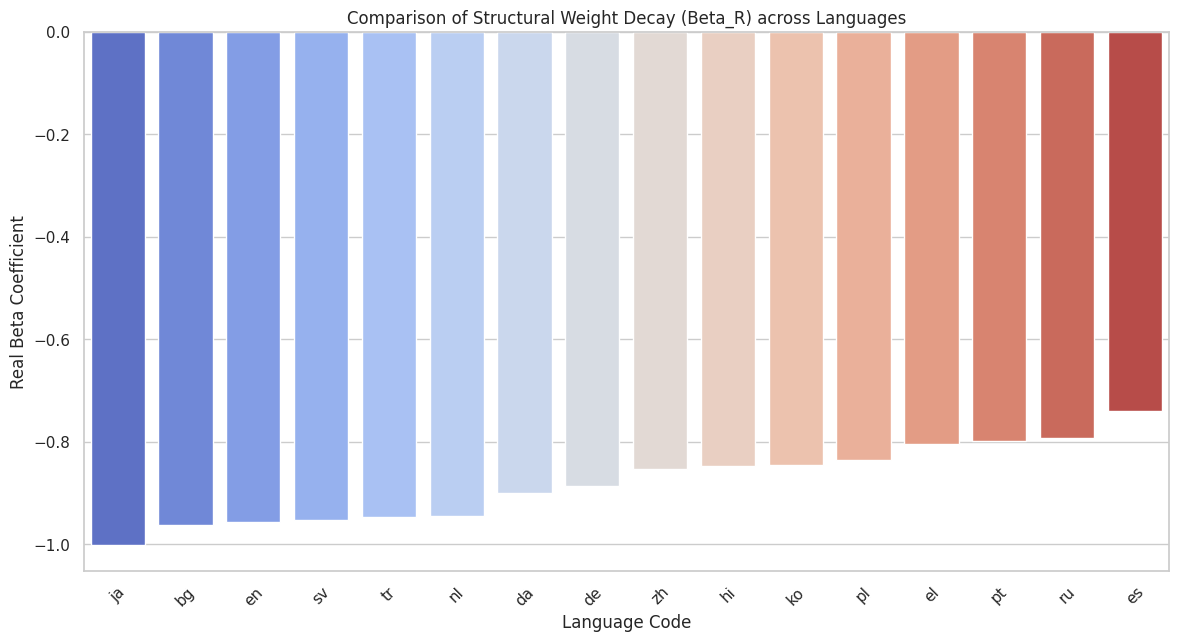

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import random
import io
import math
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from conllu import parse_incr
from google.colab import drive
from scipy.stats import norm

warnings.filterwarnings('ignore')

drive_root = "/content/drive/MyDrive/Course_Project"
save_dir = os.path.join(drive_root, "Subtree_Weight_Analysis")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

def get_subtree_weights(sentence):
    weights = {}
    for word in sentence:
        if isinstance(word['id'], int):
            weights[word['id']] = 1
        else:
            continue

    heads = {}
    for word in sentence:
        if isinstance(word['id'], int):
            head_val = word['head']
            if isinstance(head_val, int):
                heads[word['id']] = head_val
            elif head_val is None:
                heads[word['id']] = 0
            else:
                try:
                    heads[word['id']] = int(head_val)
                except (ValueError, TypeError):
                    heads[word['id']] = 0

    ids = sorted(weights.keys(), reverse=True)

    for i in ids:
        h = heads.get(i)
        if isinstance(h, int) and h in weights:
            weights[h] += weights[i]
    return weights

def extract_obs(sentence, weights, shuffle=False):
    nodes = [word['id'] for word in sentence if isinstance(word['id'], int)]
    if shuffle:
        shf = list(nodes)
        random.shuffle(shf)
        pos = {node: i for i, node in enumerate(shf)}
    else:
        pos = {node: i for i, node in enumerate(nodes)}

    obs = []
    for word in sentence:
        if not isinstance(word['id'], int) or not isinstance(word['head'], int):
            continue

        h_id, d_id = word['head'], word['id']
        if h_id == 0 or h_id is None: continue

        if h_id not in pos or d_id not in pos: continue

        p1, p2 = pos[h_id], pos[d_id]
        l, r = min(p1, p2), max(p1, p2)
        dist = r - l
        if dist > 1:
            for n_id, p_val in pos.items():
                if l < p_val < r:
                    obs.append({'dist': dist, 'weight': weights[n_id]})
    return obs

def run_model(data):
    if not data: return None, None, None
    df = pd.DataFrame(data)
    counts = df.groupby(['dist', 'weight']).size().reset_index(name='y')
    counts['log_dist'] = np.log(counts['dist'])
    X = sm.add_constant(counts[['weight']])
    try:
        res = sm.GLM(counts['y'], X, family=sm.families.Poisson(), offset=counts['log_dist']).fit()
        return res.params['weight'], res.bse['weight'], res.tvalues['weight']
    except:
        return None, None, None

conllu_files = [f for f in os.listdir(drive_root) if f.endswith('.conllu')]
all_results = []

header = "{:<6} | {:<8} | {:<8} | {:<8} | {:<12}"
print(header.format("Lang", "Beta_R", "Wald_Z", "Z_Diff", "Conclusion"))
print("-" * 55)

for f_name in conllu_files:
    lang = f_name.split('_')[0]
    path = os.path.join(drive_root, f_name)
    r_obs, s_obs = [], []
    with io.open(path, "r", encoding="utf-8") as f:
        for sent in parse_incr(f):
            w = get_subtree_weights(sent)
            r_obs.extend(extract_obs(sent, w, False))
            s_obs.extend(extract_obs(sent, w, True))

    r_b, r_se, r_z = run_model(r_obs)
    s_b, s_se, s_z = run_model(s_obs)

    if r_b is not None and s_b is not None:
        z_diff = (r_b - s_b) / math.sqrt(r_se**2 + s_se**2)

        test1 = r_z < -1.645
        test2 = z_diff < -1.645

        conc = "Efficient" if (test1 and test2) else "Insignificant"

        all_results.append({
            'Language': lang,
            'Real_Beta': r_b,
            'Real_Wald_Z': r_z,
            'Rand_Beta': s_b,
            'Rand_Wald_Z': s_z,
            'Z_Diff': z_diff,
            'Conclusion': conc
        })
        print(header.format(lang, round(r_b, 3), round(r_z, 2), round(z_diff, 2), conc))

df_final = pd.DataFrame(all_results)
df_final.to_csv(os.path.join(save_dir, "dual_test_results.csv"), index=False)

plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")
plot_data = df_final.sort_values("Real_Beta")
sns.barplot(x="Language", y="Real_Beta", data=plot_data, palette="coolwarm")
plt.title("Comparison of Structural Weight Decay (Beta_R) across Languages")
plt.ylabel("Real Beta Coefficient")
plt.xlabel("Language Code")
plt.xticks(rotation=45)

plot_save_path = os.path.join(save_dir, "beta_r_distribution.png")
plt.savefig(plot_save_path, bbox_inches='tight', dpi=300)
plt.show()

Mounted at /content/drive


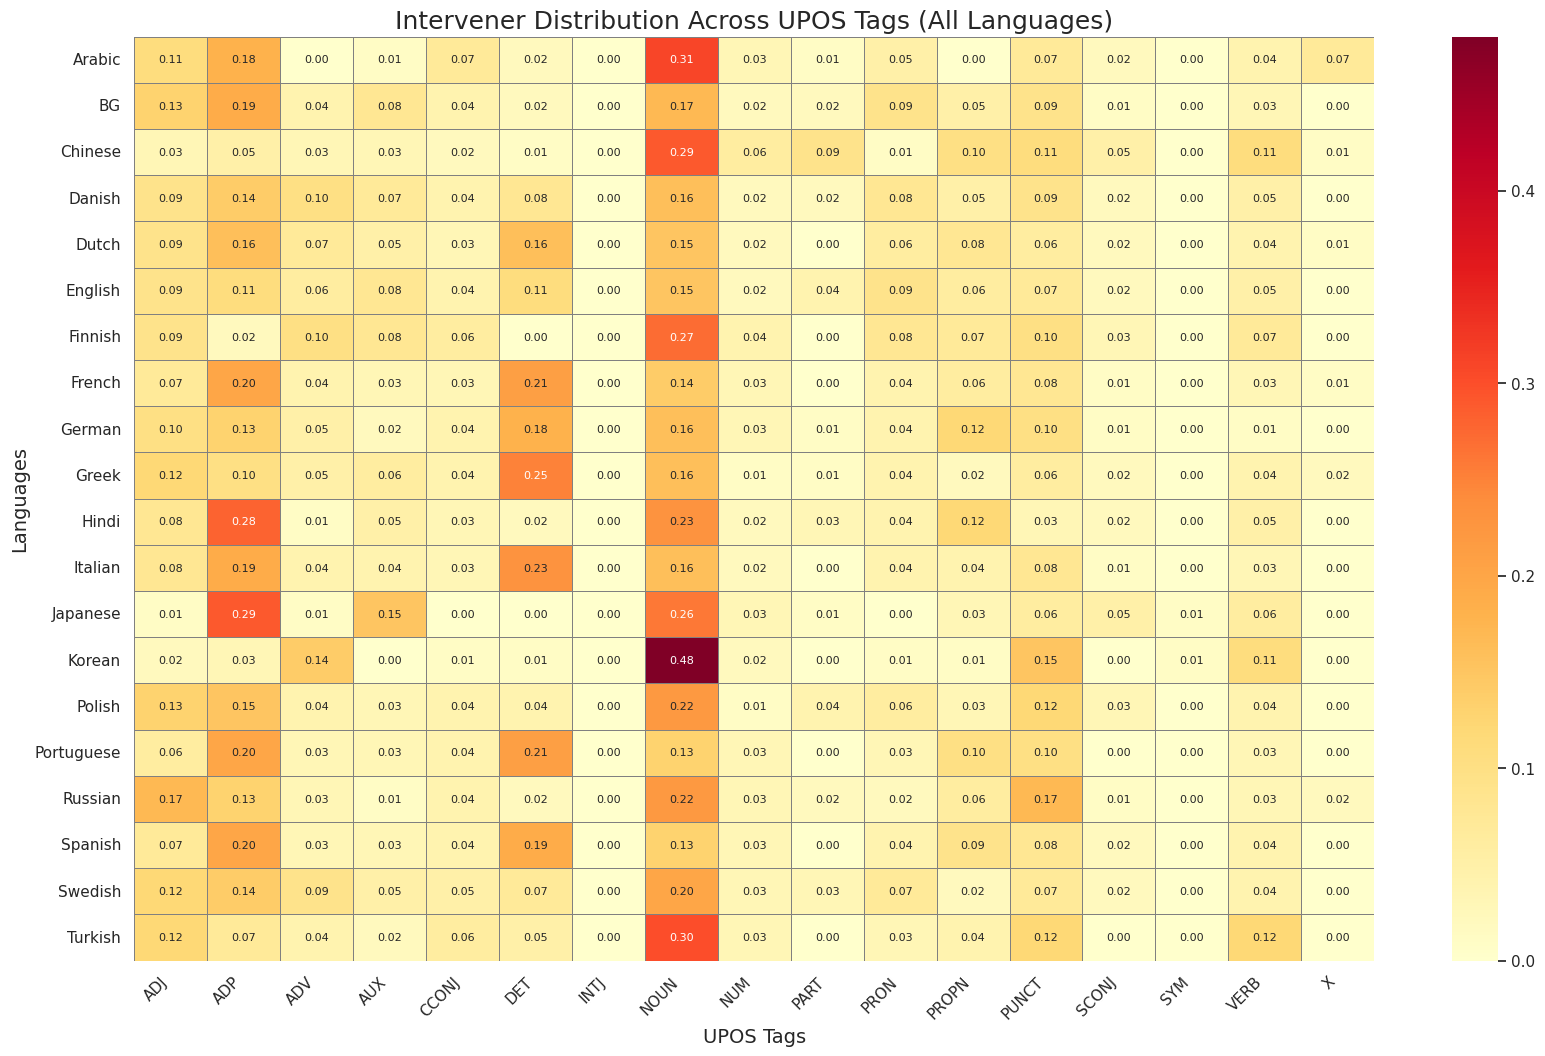

In [ ]:
import os
import networkx as nx
import conllu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import shutil

if os.path.ismount('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass

if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except:
            pass

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/Course_Project"
data_path = drive_path
output_path = os.path.join(drive_path, "UPOS_Analysis")

os.makedirs(output_path, exist_ok=True)

lang_map = {
    'EN': 'English', 'HI': 'Hindi', 'DE': 'German', 'FR': 'French', 'ES': 'Spanish',
    'IT': 'Italian', 'RU': 'Russian', 'ZH': 'Chinese', 'JA': 'Japanese', 'KO': 'Korean',
    'AR': 'Arabic', 'TR': 'Turkish', 'FI': 'Finnish', 'EL': 'Greek', 'SV': 'Swedish',
    'PL': 'Polish', 'DA': 'Danish', 'NL': 'Dutch', 'PT': 'Portuguese', 'RO': 'Romanian'
}

with open("Measures_rand.py", "w") as f:
    f.write("""
import networkx as nx

class Compute_measures_rand(object):
    def __init__(self, tree, root):
        self.tree = tree
        self.root = root

    def get_interveners(self, edge):
        nodes = sorted([n for n in self.tree.nodes if n != self.root])
        h, d = edge
        if h > d:
            return [n for n in nodes if d < n < h]
        return [n for n in nodes if h < n < d]
""")

from Measures_rand import Compute_measures_rand

def conduct_pos_analysis(directory):
    files = sorted([f for f in os.listdir(directory) if f.endswith('.conllu')])
    master_data = []

    for file in files:
        lang_code = file.split('_')[0].upper()
        file_path = os.path.join(directory, file)
        full_name = lang_map.get(lang_code, lang_code)

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                for sent in conllu.parse_incr(f):
                    G = nx.DiGraph()
                    G.add_node(0, upos="ROOT")

                    for t in sent:
                        if isinstance(t['id'], int):
                            G.add_node(t['id'], upos=t['upostag'])

                    for t in sent:
                        if isinstance(t['id'], int):
                            G.add_edge(t['head'], t['id'])

                    measurer = Compute_measures_rand(G, 0)

                    for h, d in G.edges():
                        if h == 0:
                            continue

                        intervener_ids = measurer.get_interveners((h, d))

                        for int_id in intervener_ids:
                            tag = G.nodes[int_id].get('upos', 'UNKNOWN')
                            master_data.append({"Language": full_name, "UPOS": tag})

        except:
            pass

    return pd.DataFrame(master_data)

df_pos = conduct_pos_analysis(data_path)

heatmap_data = df_pos.groupby(['Language', 'UPOS']).size().unstack(fill_value=0)
heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).round(2)

plt.figure(figsize=(20, 12))

sns.heatmap(
    heatmap_normalized,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 8}
)

plt.title("Intervener Distribution Across UPOS Tags (All Languages)", fontsize=18)
plt.xlabel("UPOS Tags", fontsize=14)
plt.ylabel("Languages", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

heatmap_path = os.path.join(output_path, "upos_heatmap_annotated.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')

plt.show()

heatmap_data.to_csv(os.path.join(output_path, "upos_heatmap_raw.csv"))
heatmap_normalized.to_csv(os.path.join(output_path, "upos_heatmap_normalized.csv"))

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import io

drive_path = "/content/drive/MyDrive/Course_Project"
output_path = os.path.join(drive_path, "UPOS_Analysis")

lang_map = {
    'EN': 'English', 'HI': 'Hindi', 'DE': 'German', 'FR': 'French', 'ES': 'Spanish',
    'IT': 'Italian', 'RU': 'Russian', 'ZH': 'Chinese', 'JA': 'Japanese', 'KO': 'Korean',
    'AR': 'Arabic', 'TR': 'Turkish', 'FI': 'Finnish', 'EL': 'Greek', 'SV': 'Swedish',
    'PL': 'Polish', 'DA': 'Danish', 'NL': 'Dutch', 'PT': 'Portuguese', 'RO': 'Romanian'
}

def get_counts(file_path):
    obs = []
    with io.open(file_path, 'r', encoding='utf-8') as f:
        sent = []
        for line in f:
            line = line.strip()
            if not line:
                if sent:
                    tag_map = {w['id']: w['upos'] for w in sent}
                    for w in sent:
                        h, d = w['head'], w['id']
                        if h == 0: continue
                        dist = abs(h - d)
                        start, end = min(h, d), max(h, d)
                        for i in range(start + 1, end):
                            tag = tag_map.get(i)
                            if tag:
                                obs.append({'Distance': dist, 'Tag': tag})
                    sent = []
                continue
            if line.startswith('#'): continue
            p = line.split('\t')
            if '-' in p[0] or '.' in p[0]: continue
            sent.append({'id': int(p[0]), 'upos': p[3], 'head': int(p[6])})

    df = pd.DataFrame(obs)
    return df.groupby(['Distance', 'Tag']).size().reset_index(name='Count')

files = sorted([f for f in os.listdir(drive_path) if f.endswith('.conllu')])
all_lang_results = []

for f_name in files:
    lang_code = f_name.split('_')[0].upper()
    lang_name = lang_map.get(lang_code, lang_code)

    try:
        data = get_counts(os.path.join(drive_path, f_name))
        model = smf.glm("Count ~ Distance + C(Tag, Treatment(reference='VERB'))",
                        data=data,
                        family=sm.families.Poisson()).fit()

        row = {'Language': lang_name, 'Beta_Nought': model.params['Intercept']}

        for param_name, value in model.params.items():
            if 'T.' in param_name:
                tag = param_name.split('.')[-1][:-1]
                row['IRR_' + tag] = np.exp(value)

        row['IRR_VERB'] = 1.0
        all_lang_results.append(row)
        print("Processed: {}".format(lang_name))

    except Exception as e:
        print("Failed {}: {}".format(lang_name, str(e)))

final_df = pd.DataFrame(all_lang_results)
cols = ['Language', 'Beta_Nought'] + [c for c in final_df.columns if c.startswith('IRR_')]
final_df = final_df[cols].fillna(0)

final_df.to_csv(os.path.join(output_path, "upos_glm_summary_table.csv"), index=False)

print("\n--- Final Summary Table (First 10 Rows) ---")
print(final_df.head(10))

Processed: Arabic
Processed: BG
Processed: Danish
Processed: German
Processed: Greek
Processed: English
Processed: Spanish
Processed: Finnish
Processed: French
Processed: Hindi
Processed: Italian
Processed: Japanese
Processed: Korean
Processed: Dutch
Processed: Polish
Processed: Portuguese
Processed: Russian
Processed: Swedish
Processed: Turkish
Processed: Chinese

--- Final Summary Table (First 10 Rows) ---
  Language  Beta_Nought   IRR_ADJ   IRR_ADP   IRR_ADV   IRR_AUX  IRR_CCONJ  \
0   Arabic     6.727557  2.597005  4.120357  0.099550  0.236742   1.592026   
1       BG     6.998571  4.069955  5.861231  1.359364  2.520441   1.221711   
2   Danish     6.776056  2.007283  3.080230  2.172912  1.439328   0.868351   
3   German     6.962592  6.772969  8.970692  3.346986  1.360697   2.573304   
4    Greek     5.741942  2.821493  2.436977  1.143033  1.393513   0.991630   
5  English     7.741220  1.675163  2.136223  1.095545  1.569611   0.803948   
6  Spanish     7.718243  1.862932  5.76383

Parsing 20 files...
Global Analysis Complete. Beta_0 (Intercept): 10.2109


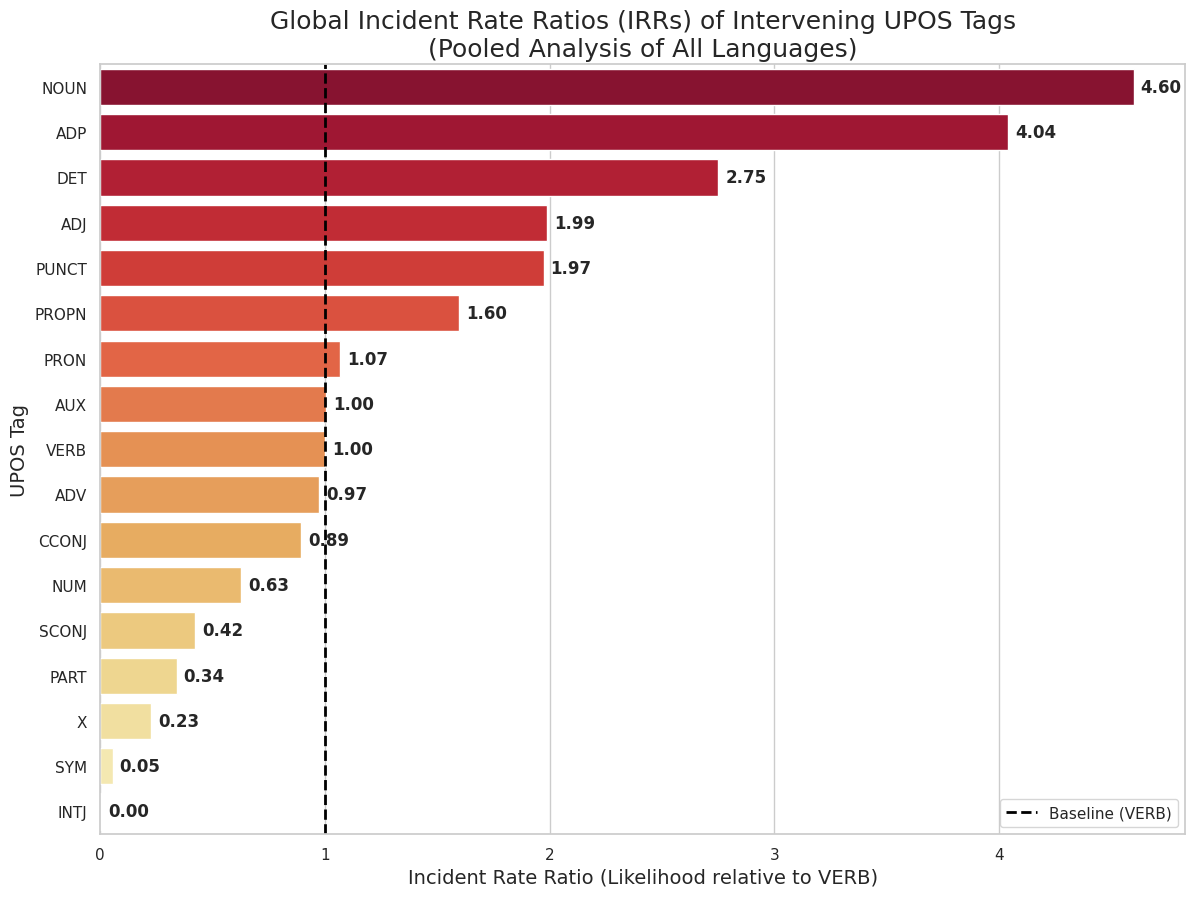

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

drive_path = "/content/drive/MyDrive/Course_Project"
output_path = os.path.join(drive_path, "UPOS_Analysis")

def extract_global_data(directory):
    all_obs = []
    files = [f for f in os.listdir(directory) if f.endswith('.conllu')]
    print("Parsing {} files...".format(len(files)))

    for filename in files:
        with io.open(os.path.join(directory, filename), 'r', encoding='utf-8') as f:
            sent = []
            for line in f:
                line = line.strip()
                if not line:
                    if sent:
                        tag_map = {w['id']: w['upos'] for w in sent}
                        for w in sent:
                            h, d = w['head'], w['id']
                            if h == 0: continue
                            dist = abs(h - d)
                            start, end = min(h, d), max(h, d)
                            for i in range(start + 1, end):
                                if i in tag_map:
                                    all_obs.append({'Distance': dist, 'Tag': tag_map[i]})
                        sent = []
                    continue
                if line.startswith('#'): continue
                p = line.split('\t')
                if '-' in p[0] or '.' in p[0]: continue
                sent.append({'id': int(p[0]), 'upos': p[3], 'head': int(p[6])})

    df = pd.DataFrame(all_obs)
    return df.groupby(['Distance', 'Tag']).size().reset_index(name='Count')

global_counts = extract_global_data(drive_path)

model = smf.glm("Count ~ Distance + C(Tag, Treatment(reference='VERB'))",
                data=global_counts,
                family=sm.families.Poisson()).fit()

results = pd.DataFrame({'Beta': model.params})
results['IRR'] = np.exp(results['Beta'])

results = results.reset_index()
results['UPOS'] = results['index'].apply(lambda x: x.split('.')[-1][:-1] if 'T.' in x else ('VERB' if 'Intercept' in x else x))
results = results[results['index'] != 'Distance']
results.at[results[results['UPOS'] == 'VERB'].index[0], 'IRR'] = 1.0

results = results.sort_values(by='IRR', ascending=False)

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
palette = sns.color_palette("YlOrRd_r", len(results))

ax = sns.barplot(x='IRR', y='UPOS', data=results, hue='UPOS', palette=palette, legend=False)
plt.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Baseline (VERB)')

for i, p in enumerate(ax.patches):
    ax.annotate("%.2f" % p.get_width(), (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', ha='left', va='center', fontweight='bold')

plt.title("Global Incident Rate Ratios (IRRs) of Intervening UPOS Tags\n(Pooled Analysis of All Languages)", fontsize=18)
plt.xlabel("Incident Rate Ratio (Likelihood relative to VERB)", fontsize=14)
plt.ylabel("UPOS Tag", fontsize=14)
plt.legend(loc='lower right')

plt.savefig(os.path.join(output_path, "global_upos_dominance.png"), dpi=300, bbox_inches='tight')
results.to_csv(os.path.join(output_path, "global_upos_results.csv"), index=False)

print("Global Analysis Complete. Beta_0 (Intercept): {:.4f}".format(model.params['Intercept']))

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import io
from scipy.stats import chi2
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/Course_Project"
output_path = os.path.join(drive_path, "UPOS_Analysis")
if not os.path.exists(output_path):
    os.makedirs(output_path)

lang_map = {
    'EN': 'English', 'HI': 'Hindi', 'DE': 'German', 'FR': 'French', 'ES': 'Spanish',
    'IT': 'Italian', 'RU': 'Russian', 'ZH': 'Chinese', 'JA': 'Japanese', 'KO': 'Korean',
    'AR': 'Arabic', 'TR': 'Turkish', 'FI': 'Finnish', 'EL': 'Greek', 'SV': 'Swedish',
    'PL': 'Polish', 'DA': 'Danish', 'NL': 'Dutch', 'PT': 'Portuguese', 'RO': 'Romanian'
}

def analyze_language(file_path):
    obs = []
    with io.open(file_path, 'r', encoding='utf-8') as f:
        sent = []
        for line in f:
            line = line.strip()
            if not line:
                if sent:
                    id_map = {w['id']: w['upos'] for w in sent}
                    for w in sent:
                        h, d = w['head'], w['id']
                        if h == 0: continue
                        dist, start, end = abs(h - d), min(h, d), max(h, d)
                        for i in range(start + 1, end):
                            if i in id_map:
                                obs.append({'Distance': dist, 'Tag': id_map[i]})
                    sent = []
                continue
            if line.startswith('#'): continue
            p = line.split('\t')
            if '-' in p[0] or '.' in p[0]: continue
            sent.append({'id': int(p[0]), 'upos': p[3], 'head': int(p[6])})

    df = pd.DataFrame(obs)
    counts = df.groupby(['Distance', 'Tag']).size().reset_index(name='Count')
    return counts

files = sorted([f for f in os.listdir(drive_path) if f.endswith('.conllu')])
final_results = []

for filename in files:
    lang_code = filename.split('_')[0].upper()
    lang_name = lang_map.get(lang_code, lang_code)
    print("Testing: {}".format(lang_name))

    try:
        data = analyze_language(os.path.join(drive_path, filename))

        m0 = smf.glm("Count ~ Distance", data=data, family=sm.families.Poisson()).fit()
        m1 = smf.glm("Count ~ Distance + C(Tag, Treatment(reference='VERB'))",
                     data=data, family=sm.families.Poisson()).fit()

        lrt_stat = 2 * (m1.llf - m0.llf)
        p_lrt = chi2.sf(lrt_stat, df=len(m1.params) - len(m0.params))
        reject_lrt = "Yes" if p_lrt < 0.05 else "No"

        params = m1.params.drop(['Intercept', 'Distance'])
        others = params.drop([k for k in params.index if 'NOUN' in k or 'ADP' in k])
        next_highest_tag = others.idxmax()
        beta_next = others.max()
        se_next = m1.bse[next_highest_tag]

        lang_output = {
            'Language': lang_name,
            'LRT_Stat': lrt_stat,
            'LRT_Reject_H0': reject_lrt
        }

        for target in ['NOUN', 'ADP']:
            key = [k for k in m1.params.index if target in k][0]
            beta_t = m1.params[key]
            se_t = m1.bse[key]

            z_val = (beta_t - beta_next) / np.sqrt(se_t**2 + se_next**2)
            reject_dom = "Yes" if z_val > 1.645 else "No"

            lang_output[target + '_Beta'] = beta_t
            lang_output[target + '_Wald_Z'] = z_val
            lang_output[target + '_Dominant'] = reject_dom

        final_results.append(lang_output)

    except Exception as e:
        print("Error in {}: {}".format(lang_name, str(e)))

results_df = pd.DataFrame(final_results)
results_df.to_csv(os.path.join(output_path, "hypothesis_testing_results.csv"), index=False)
print("\n--- Final Hypothesis Test Summary ---")
print(results_df)

Mounted at /content/drive
Testing: Arabic
Testing: BG
Testing: Danish
Testing: German
Testing: Greek
Testing: English
Testing: Spanish
Testing: Finnish
Testing: French
Testing: Hindi
Testing: Italian
Testing: Japanese
Testing: Korean
Testing: Dutch
Testing: Polish
Testing: Portuguese
Testing: Russian
Testing: Swedish
Testing: Turkish
Testing: Chinese

--- Final Hypothesis Test Summary ---
      Language       LRT_Stat LRT_Reject_H0  NOUN_Beta  NOUN_Wald_Z  \
0       Arabic  861095.143101           Yes   1.985156   111.889397   
1           BG  161232.503616           Yes   1.643999    13.213230   
2       Danish  115851.801791           Yes   1.275444    27.837564   
3       German  640199.092431           Yes   2.371103    -7.673784   
4        Greek   77360.294119           Yes   1.384200   -17.459817   
5      English  266351.849427           Yes   1.103768    30.361516   
6      Spanish  833958.495033           Yes   1.346517   -40.895921   
7      Finnish  253756.399931           

Mount point /content/drive is not empty. Clearing contents...
Mount point cleared.
Mounted at /content/drive
Parsing 20 files (Shuffling=True)...
Analysis Complete. Results saved to: /content/drive/MyDrive/Course_Project/UPOS_Analysis
Beta_0 (Intercept): 11.7864


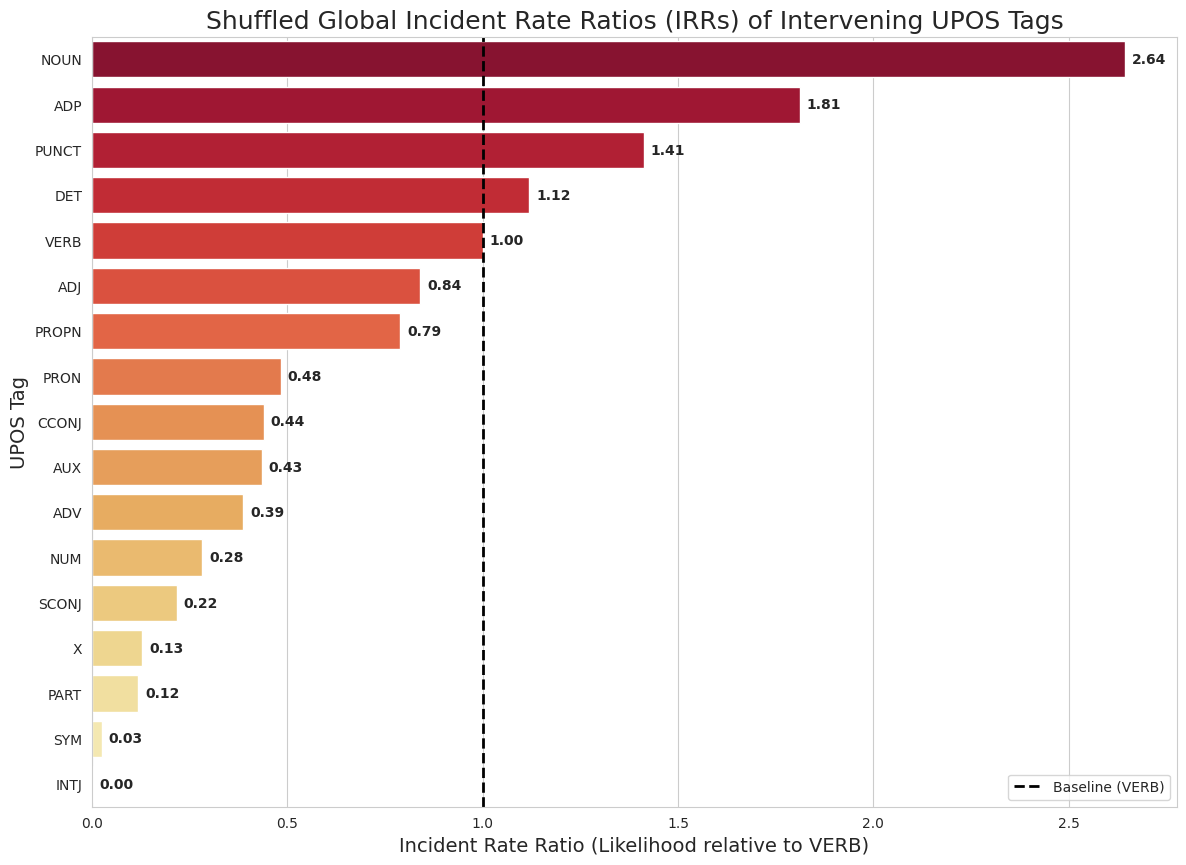

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import random
from google.colab import drive
import shutil

if os.path.ismount('/content/drive'):
    try:
        drive.flush_and_unmount()
        print("Drive unmounted successfully.")
    except Exception as e:
        print(f"Error unmounting drive: {e}")

if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    if os.listdir('/content/drive'):
        print("Mount point /content/drive is not empty. Clearing contents...")
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            try:
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.unlink(item_path)
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
            except Exception as e:
                print(f"Error clearing item {item_path}: {e}")
        print("Mount point cleared.")
else:
    os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/Course_Project"
output_path = os.path.join(drive_path, "UPOS_Analysis")

if not os.path.exists(output_path):
    os.makedirs(output_path)

def extract_global_data(directory, shuffle_words=True):
    all_obs = []

    files = [f for f in os.listdir(directory) if f.endswith('.conllu')]
    if not files:
        print(f" No files found in {directory}. Check your path and shortcuts.")
        return pd.DataFrame()

    print(f"Parsing {len(files)} files (Shuffling={shuffle_words})...")

    for filename in files:
        with io.open(os.path.join(directory, filename), 'r', encoding='utf-8') as f:
            sent = []
            for line in f:
                line = line.strip()
                if not line:
                    if sent:

                        if shuffle_words:

                            original_ids = [w['id'] for w in sent]
                            new_positions = random.sample(original_ids, len(original_ids))
                            id_map = dict(zip(original_ids, new_positions))

                            for w in sent:
                                w['id'] = id_map[w['id']]
                                if w['head'] != 0 and w['head'] in id_map:
                                    w['head'] = id_map[w['head']]


                        tag_map = {w['id']: w['upos'] for w in sent}
                        for w in sent:
                            h, d = w['head'], w['id']
                            if h == 0: continue

                            dist = abs(h - d)
                            start, end = min(h, d), max(h, d)

                            for i in range(start + 1, end):
                                if i in tag_map:
                                    all_obs.append({'Distance': dist, 'Tag': tag_map[i]})
                        sent = []
                    continue

                if line.startswith('#'): continue
                p = line.split('\t')
                if '-' in p[0] or '.' in p[0]: continue
                sent.append({'id': int(p[0]), 'upos': p[3], 'head': int(p[6])})

    df = pd.DataFrame(all_obs)
    if df.empty:
        return df
    return df.groupby(['Distance', 'Tag']).size().reset_index(name='Count')

global_counts = extract_global_data(drive_path, shuffle_words=True)

if not global_counts.empty:
    model = smf.glm("Count ~ Distance + C(Tag, Treatment(reference='VERB'))",
                    data=global_counts,
                    family=sm.families.Poisson()).fit()

    results = pd.DataFrame({'Beta': model.params})
    results['IRR'] = np.exp(results['Beta'])

    results = results.reset_index()
    results['UPOS'] = results['index'].apply(lambda x: x.split('.')[-1][:-1] if 'T.' in x else ('VERB' if 'Intercept' in x else x))
    results = results[results['index'] != 'Distance']

    verb_idx = results[results['UPOS'] == 'VERB'].index
    if not verb_idx.empty:
        results.at[verb_idx[0], 'IRR'] = 1.0

    results = results.sort_values(by='IRR', ascending=False)

    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")
    palette = sns.color_palette("YlOrRd_r", len(results))

    ax = sns.barplot(x='IRR', y='UPOS', data=results, hue='UPOS', palette=palette, legend=False)
    plt.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Baseline (VERB)')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        ax.annotate("%.2f" % width, (width, p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points', ha='left', va='center', fontweight='bold')

    plt.title("Shuffled Global Incident Rate Ratios (IRRs) of Intervening UPOS Tags", fontsize=18)
    plt.xlabel("Incident Rate Ratio (Likelihood relative to VERB)", fontsize=14)
    plt.ylabel("UPOS Tag", fontsize=14)
    plt.legend(loc='lower right')

    plt.savefig(os.path.join(output_path, "shuffled_upos_dominance.png"), dpi=300, bbox_inches='tight')
    results.to_csv(os.path.join(output_path, "shuffled_upos_results.csv"), index=False)

    print(f"Analysis Complete. Results saved to: {output_path}")
    print("Beta_0 (Intercept): {:.4f}".format(model.params['Intercept']))
else:
    print("Failed-Execution.")

Lang   | Beta_S   | Wald_Z   | Z_Diff   | Conclusion  
-------------------------------------------------------
en     |   -0.546 | -1175.32 |  -262.47 | Efficient   
hi     |   -0.594 | -1284.52 |  -213.17 | Efficient   
de     |   -0.588 | -1301.53 |  -247.70 | Efficient   
es     |   -0.451 | -1964.25 |  -323.89 | Efficient   
ru     |   -0.457 |  -729.83 |  -153.68 | Efficient   
zh     |   -0.604 |  -923.09 |  -137.56 | Efficient   
ja     |   -0.563 | -1240.89 |  -220.19 | Efficient   
ko     |   -0.575 |  -536.68 |   -90.53 | Efficient   
tr     |   -0.652 |  -370.13 |   -63.45 | Efficient   
el     |   -0.463 |  -638.43 |  -121.41 | Efficient   
sv     |   -0.569 |  -595.51 |  -133.48 | Efficient   
pl     |   -0.487 | -1277.75 |  -282.29 | Efficient   
da     |   -0.539 |  -761.66 |  -157.47 | Efficient   
nl     |   -0.625 | -1053.60 |  -201.62 | Efficient   
pt     |   -0.450 | -1572.97 |  -302.72 | Efficient   
bg     |   -0.560 |  -764.68 |  -175.74 | Efficient   


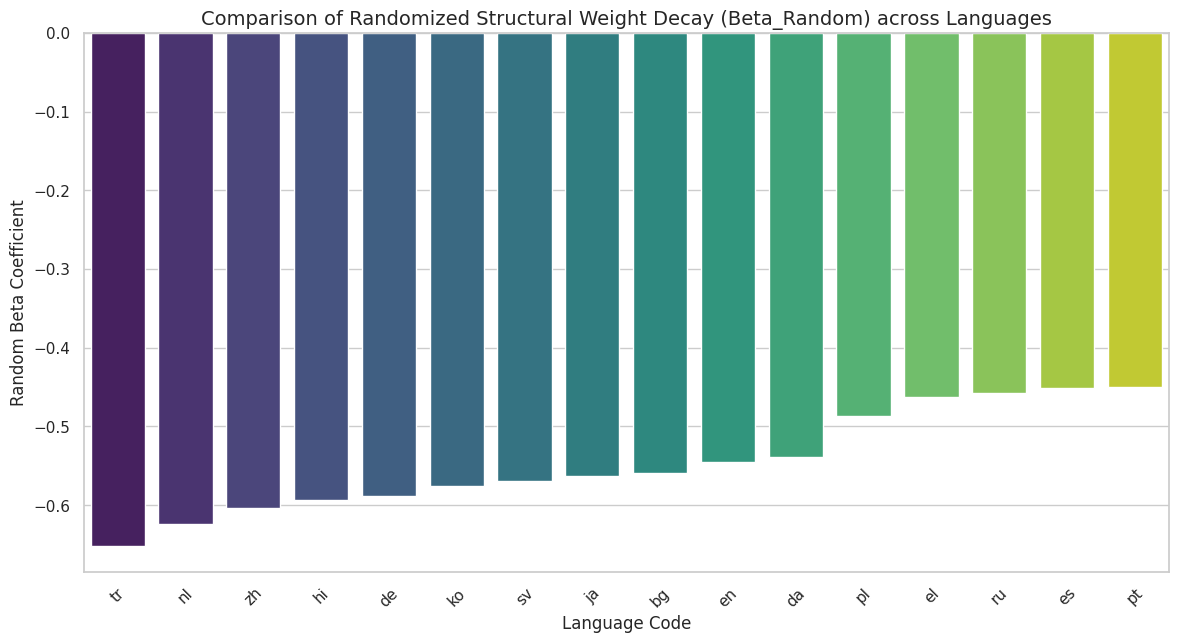

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import random
import io
import math
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from conllu import parse_incr
from google.colab import drive
from scipy.stats import norm

warnings.filterwarnings('ignore')

def setup_environment(root_path):
    base_path = Path(root_path)
    output_path = base_path / "Subtree_Weight_Analysis"
    output_path.mkdir(parents=True, exist_ok=True)

    if not Path("/content/drive").exists():
        drive.mount('/content/drive')

    return base_path, output_path

def get_subtree_weights(sentence):
    weights = {word['id']: 1 for word in sentence if isinstance(word['id'], int)}
    heads = {word['id']: (int(word['head']) if isinstance(word['head'], (int, float)) else 0)
             for word in sentence if isinstance(word['id'], int)}

    for i in sorted(weights.keys(), reverse=True):
        h = heads.get(i, 0)
        if h in weights:
            weights[h] += weights[i]
    return weights

def extract_obs(sentence, weights, shuffle=False):
    nodes = [word['id'] for word in sentence if isinstance(word['id'], int)]
    if shuffle:
        shuffled = random.sample(nodes, len(nodes))
        pos = {node: i for i, node in enumerate(shuffled)}
    else:
        pos = {node: i for i, node in enumerate(nodes)}

    observations = []
    for word in sentence:
        if not isinstance(word['id'], int) or not isinstance(word['head'], int):
            continue

        h_id, d_id = word['head'], word['id']
        if h_id == 0 or h_id not in pos or d_id not in pos:
            continue

        p1, p2 = pos[h_id], pos[d_id]
        l, r = min(p1, p2), max(p1, p2)
        dist = r - l

        if dist > 1:
            observations.extend([{'dist': dist, 'weight': weights[n_id]}
                                 for n_id, p_val in pos.items() if l < p_val < r])
    return observations

def run_model(data):
    if not data:
        return None, None, None

    df = pd.DataFrame(data)
    counts = df.groupby(['dist', 'weight']).size().reset_index(name='y')
    counts['log_dist'] = np.log(counts['dist'])

    X = sm.add_constant(counts[['weight']])
    try:
        model = sm.GLM(counts['y'], X, family=sm.families.Poisson(), offset=counts['log_dist']).fit()
        return model.params['weight'], model.bse['weight'], model.tvalues['weight']
    except Exception:
        return None, None, None

def main():
    drive_root, save_dir = setup_environment("/content/drive/MyDrive/Course_Project")
    conllu_files = list(drive_root.glob('*.conllu'))

    results = []
    print(f"{'Lang':<6} | {'Beta_S':<8} | {'Wald_Z':<8} | {'Z_Diff':<8} | {'Conclusion':<12}")
    print("-" * 55)

    for file_path in conllu_files:
        lang = file_path.stem.split('_')[0]
        real_obs, rand_obs = [], []

        with open(file_path, "r", encoding="utf-8") as f:
            for sent in parse_incr(f):
                w = get_subtree_weights(sent)
                real_obs.extend(extract_obs(sent, w, False))
                rand_obs.extend(extract_obs(sent, w, True))

        r_b, r_se, r_z = run_model(real_obs)
        s_b, s_se, s_z = run_model(rand_obs)

        if r_b is not None and s_b is not None:
            z_diff = (r_b - s_b) / math.sqrt(r_se**2 + s_se**2)
            is_efficient = r_z < -1.645 and z_diff < -1.645
            conclusion = "Efficient" if is_efficient else "Insignificant"

            results.append({
                'Language': lang, 'Real_Beta': r_b, 'Real_Wald_Z': r_z,
                'Rand_Beta': s_b, 'Rand_Wald_Z': s_z, 'Z_Diff': z_diff,
                'Conclusion': conclusion
            })
            print(f"{lang:<6} | {s_b:>8.3f} | {s_z:>8.2f} | {z_diff:>8.2f} | {conclusion:<12}")

    if not results:
        return

    df_final = pd.DataFrame(results)
    df_final.to_csv(save_dir / "dual_test_results.csv", index=False)

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    plot_data = df_final.sort_values("Rand_Beta")

    sns.barplot(data=plot_data, x="Language", y="Rand_Beta", hue="Language", palette="viridis", legend=False)

    plt.title("Comparison of Randomized Structural Weight Decay (Beta_Random) across Languages", fontsize=14)
    plt.ylabel("Random Beta Coefficient", fontsize=12)
    plt.xlabel("Language Code", fontsize=12)
    plt.xticks(rotation=45)

    plt.savefig(save_dir / "beta_random_distribution.png", bbox_inches='tight', dpi=300)
    plt.show()

if __name__ == "__main__":
    main()